In [1]:
import numpy as np
import matplotlib.pyplot as plt

# AWS imports: Import Braket SDK modules
from braket.circuits import Circuit, Gate, Observable
from braket.devices import LocalSimulator
from braket.aws import AwsDevice, AwsQuantumTask
from braket.tracking import Tracker

from scipy.sparse.linalg import expm_multiply
from scipy.sparse import diags, lil_matrix
from utils import *

import sys
sys.path.append('../SimuQ')

In [2]:
from simuq.solver import generate_as
from systems.pde import GenQS
from aais.heis_aais import GenMach
from backends.qiskit_iontrap import transpile

# Goal: 2D PDE (after diagonalization)

Our goal is to simulate the *nonlinear* scalar hyperbolic PDE:
$$
    \partial_t u + u \partial_x u - x = 0,
$$
subject to the initial condition being Gaussian centered at $\mu$ with variance $\sigma^2$:
$$
    u(0,x) = \sin(2\pi x) / 2
$$
and with periodic boundary conditions on the interval $[-1,1]$.

By the level set method, we obtain the *linear* PDE
$$
    \partial_t \phi + x_2  \partial_{x_1} \phi + x_1 \partial_{x_2} \phi = 0,\\
    \phi(0,x_1,x_2) = \delta(x_2 - u_0(x_1)).
$$

Since this PDE involves interactions between spatial variables, we apply diagonalization to get
$$
    \partial_t \psi + y_1 \partial_{y_1} \psi - y_2 \partial_{y_2} \psi = 0,
$$
using the transformation $\psi(t,y_1,y_2) = \phi(t, (y_1 + y_2) / \sqrt{2}, (y_1 - y_2) / \sqrt{2})$.

In [227]:
N = 256
# m = 10
L = -2
R = 2


h = (R-L)/(N-1)
m = 1
omega = (m * h) ** (1/2)

T = 0.3
N_t = 64
times = np.linspace(0, T, N_t)

x, p = np.meshgrid(np.linspace(L, R, N), np.linspace(L, R, N), indexing='ij')
# X = np.stack([x0_tmp,x1_tmp], axis=-1)

mu = 0.5
sigma = 0.15

u_0 = np.sin(2 * np.pi * x) / 2#np.exp(-0.5 * ((x - mu) / sigma) ** 2) / 3
phi_0 = delta_1d(p - u_0, omega)
phi_0 /= np.linalg.norm(phi_0)



In [228]:
psi_0 = np.zeros_like(phi_0)

y_vals = np.linspace(L, R, N)

for i in range(N):
    y_1 = y_vals[i]
    for j in range(N):
        y_2 = y_vals[j]
        
        x_1 = ((y_1 + y_2) / np.sqrt(2))# % (R - L)
        x_2 = ((y_1 - y_2) / np.sqrt(2))# % (R - L)
        # psi_0[i,j] = x_2 - np.exp(-0.5 * ((x_1 - mu) / sigma) ** 2) / 3#
        psi_0[i,j] = delta_1d(x_2 - np.sin(2 * np.pi * x_1) / 2, omega)

        # psi_0[np.clip(int(np.round(y_1 * N)), 0, N-1), np.clip(int(np.round(y_2 * N)), 0, N-1)] = phi_0[i,j]


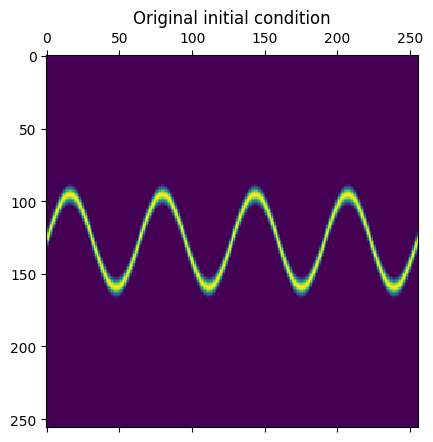

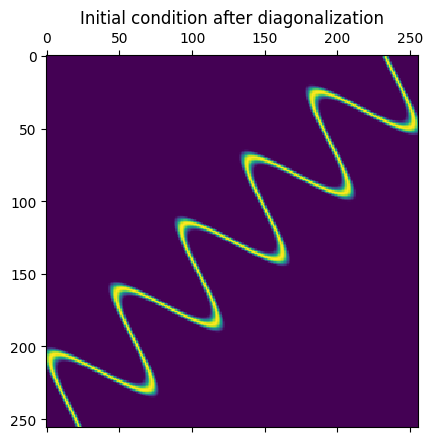

In [229]:
plt.matshow(np.rot90(phi_0))
plt.title("Original initial condition")
plt.show()
plt.matshow(np.rot90(psi_0))
plt.title("Initial condition after diagonalization")
plt.show()

In [230]:
phi_0_recover = np.zeros_like(phi_0)

for i in range(N):
    y_1 = y_vals[i]
    for j in range(N):
        y_2 = y_vals[j]
        
        x_1 = ((y_1 + y_2) / np.sqrt(2))# % (R - L)
        x_2 = ((y_1 - y_2) / np.sqrt(2))# % (R - L)
        phi_0_recover[np.clip(int((x_1 - L) * N / (R - L)), 0, N-1), np.clip(int((x_2 - L) * N / (R - L)), 0, N-1)] = psi_0[i,j]

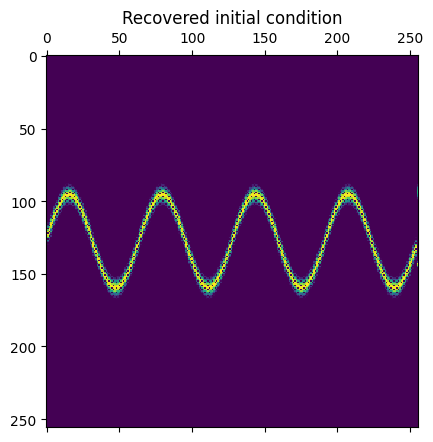

In [231]:
plt.matshow(np.rot90(phi_0_recover))
plt.title("Recovered initial condition")
plt.show()

In [232]:
x_vals = np.linspace(L, R, N)
H_phi = lil_matrix((N * N, N * N), dtype=np.complex64)
for i in range(N):

    x_1 = x_vals[i]
    for j in range(N):
        x_2 = x_vals[j]

        index = N * i + j

        # x_1 derivative
        index_x_p = N * ((i+1) % N) + j
        H_phi[index, index_x_p] = -0.5j * (x_2) / h
        H_phi[index_x_p, index] = 0.5j * (x_2) / h
        
        # x_2 derivative
        index_p_p = N * i + ((j + 1) % N)
        H_phi[index, index_p_p] = -0.5j * (x_1) / h
        H_phi[index_p_p, index] = 0.5j * (x_1) / h
        # if j-1 >= 0:
        #     index_p_m = N * i + j - 1
        #     H_phi[index, index_p_m] = 0.5j * (p_val) / h
        #     H_phi[index_p_m, index] = -0.5j * (p_val) / h

In [233]:
phi = expm_multiply(-1j * T * H_phi, phi_0.flatten()).real.reshape(N, N)

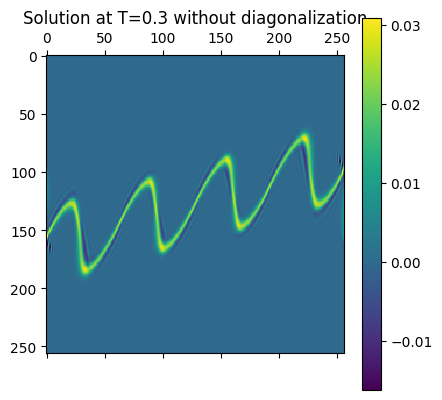

In [234]:
plt.matshow(np.rot90(phi))
plt.title(f"Solution at T={T} without diagonalization")
plt.colorbar()
plt.show()

In [235]:
x_vals = np.linspace(L, R, N)
H_psi = lil_matrix((N * N, N * N), dtype=np.complex64)
for i in range(N):

    x_1 = x_vals[i]
    for j in range(N):
        x_2 = x_vals[j]

        index = N * i + j

        # x_1 derivative
        index_x_p = N * ((i+1) % N) + j
        H_psi[index, index_x_p] = -0.5j * (x_1) / h
        H_psi[index_x_p, index] = 0.5j * (x_1) / h
        
        # x_2 derivative
        index_p_p = N * i + ((j + 1) % N)
        H_psi[index, index_p_p] = -0.5j * (-x_2) / h
        H_psi[index_p_p, index] = 0.5j * (-x_2) / h
        # if j-1 >= 0:
        #     index_p_m = N * i + j - 1
        #     H_phi[index, index_p_m] = 0.5j * (p_val) / h
        #     H_phi[index_p_m, index] = -0.5j * (p_val) / h

In [236]:
psi = expm_multiply(-1j * T * H_psi, psi_0.flatten()).real.reshape(N, N)

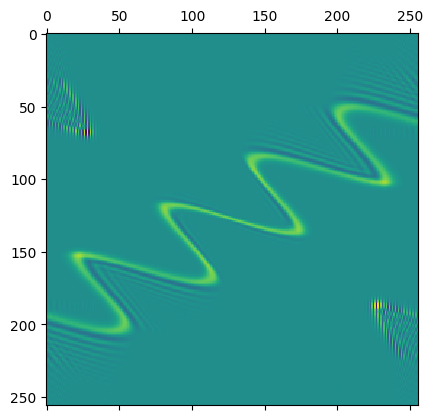

In [237]:
plt.matshow(np.rot90(psi))
plt.show()

In [238]:
phi_recover = np.zeros_like(phi_0)

for i in range(N):
    y_1 = y_vals[i]
    for j in range(N):
        y_2 = y_vals[j]
        
        x_1 = ((y_1 + y_2) / np.sqrt(2))# % (R - L)
        x_2 = ((y_1 - y_2) / np.sqrt(2))# % (R - L)
        phi_recover[np.clip(int((x_1 - L) * N / (R - L)), 0, N-1), np.clip(int((x_2 - L) * N / (R - L)), 0, N-1)] = psi[i,j]

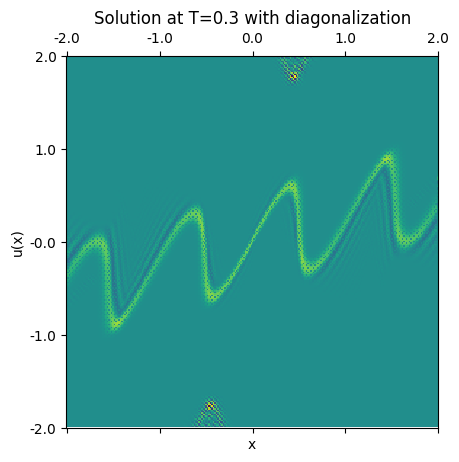

In [239]:
plt.matshow(np.rot90(phi_recover))
plt.title(f"Solution at T={T} with diagonalization")
plt.xlabel("x")
plt.xticks(np.linspace(0, N, 5), np.linspace(L, R, 5))
plt.ylabel("u(x)")
plt.yticks(np.linspace(0, N, 5), -np.linspace(L, R, 5))
plt.show()

To verify the solution, we solve the PDE using method of characteristics.

The solution is
$$
    x(t) = \left(\frac{x_0 + u_0(x_0)}{2}\right)e^{t} + \left(\frac{x_0-u_0(x_0)}{2} \right)e^{-t}, \\
    u(t) = \left(\frac{x_0 + u_0(x_0)}{2}\right)e^{t} - \left(\frac{x_0-u_0(x_0)}{2} \right)e^{-t}, \\
$$
where $u_0(x)=\sin(2\pi x) / 2$.



In [241]:
from scipy.optimize import fsolve

def u_0(x):
    return np.sin(2 * np.pi * x) / 2

def f(x_0, x, t):
    return np.exp(t) * (x_0 + u_0(x_0)) / 2 + np.exp(-t) * (x_0 - u_0(x_0)) / 2 - x

In [250]:
T = 0.3

N_t = N
u_sol = np.zeros((N_t,N))
for i, t in enumerate(np.linspace(0, T, N_t)):
    for j, x in enumerate(np.linspace(L, R, N)):
        x_0 = fsolve(f, 0, args=(x, t))[0]
        u_sol[i,j] = np.exp(t) * (x_0 + u_0(x_0)) / 2 - np.exp(-t) * (x_0 - u_0(x_0)) / 2



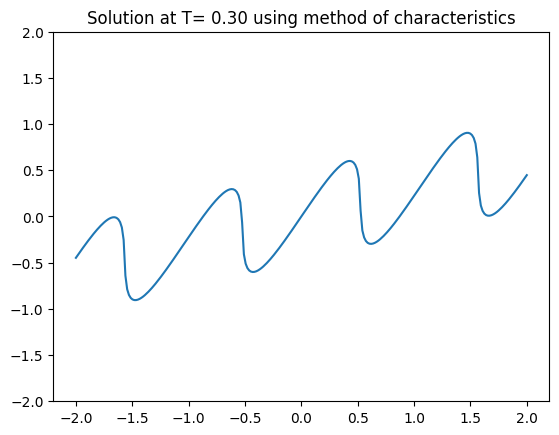

In [251]:
t_index = -1
plt.plot(np.linspace(L, R, N), u_sol[t_index,:])
plt.title(f"Solution at T={np.linspace(0, T, N_t)[t_index] : 0.2f} using method of characteristics")
plt.ylim(L, R)
plt.show()

In [1]:
# X_mesh, T_mesh = np.meshgrid(np.linspace(L, R, N), np.linspace(0, T, N_t))
# plt.contourf(X_mesh, T_mesh, u_sol)
# plt.xlabel('x')
# plt.ylabel('t')
# plt.colorbar()
# plt.show()
